In [1]:
# ============================================
# IMPORT LIBRARY
# ============================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Library berhasil di-import.")


Library berhasil di-import.


# 03 - Classification

## Prediksi Tingkat Keparahan Kecelakaan

Notebook ini membangun model klasifikasi tingkat keparahan kecelakaan lalu lintas.

Target klasifikasi: `collision_severity` dengan label `Fatal`, `Serious`, dan `Slight`.

Alur eksekusi: load data → sampling → feature engineering → decoding → feature selection
→ train/test split → preprocessing → Random Forest → prediksi → evaluasi → feature importance
→ confusion matrix.


In [2]:
# ============================================
# PROJECT PATH DAN DATASET
# ============================================

raw_dataset = Path("../data/raw/dft-road-casualty-statistics-collision-last-5-years.csv")
if not raw_dataset.exists():
    raw_dataset = Path("data/raw/dft-road-casualty-statistics-collision-last-5-years.csv")

DATA_PATH = raw_dataset
DATA_DIR = DATA_PATH.parent.parent

print("Dataset:", DATA_PATH.resolve())
print("Isi folder data:")
for file in DATA_DIR.rglob("*"):
    if file.is_file():
        print(file)


Dataset: D:\Dev\Projects\traffic-accident-ml\data\raw\dft-road-casualty-statistics-collision-last-5-years.csv
Isi folder data:
..\data\processed\stats19_maps.json
..\data\raw\dft-road-casualty-statistics-collision-last-5-years.csv


In [3]:
# ============================================
# LOAD DATASET CLASSIFICATION
# ============================================

df_class = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset berhasil dimuat.")
print("Shape:", df_class.shape)
print("Jumlah kolom:", len(df_class.columns))
print("Distribusi collision_severity:")
print(df_class["collision_severity"].value_counts(dropna=False))


Dataset berhasil dimuat.
Shape: (513801, 44)
Jumlah kolom: 44
Distribusi collision_severity:
collision_severity
3    389435
2    116813
1      7553
Name: count, dtype: int64


In [4]:
# ============================================
# SAMPLING DATA CLASSIFICATION
# 2.000 DATA PER TAHUN
# ============================================

sample_per_year = 2000
selected_years = [2021, 2022, 2023, 2024, 2025]

df_class_sample = (
    df_class[df_class["collision_year"].isin(selected_years)]
    .groupby("collision_year", group_keys=False)
    .sample(n=sample_per_year, random_state=42)
    .reset_index(drop=True)
)

print("Sampling berhasil.")
print("Shape:", df_class_sample.shape)
print("Distribusi tahun:")
print(df_class_sample["collision_year"].value_counts().sort_index())
print("Distribusi target:")
print(df_class_sample["collision_severity"].value_counts().sort_index())


Sampling berhasil.
Shape: (10000, 44)
Distribusi tahun:
collision_year
2021    2000
2022    2000
2023    2000
2024    2000
2025    2000
Name: count, dtype: int64
Distribusi target:
collision_severity
1     139
2    2266
3    7595
Name: count, dtype: int64


In [5]:
# ============================================
# FEATURE ENGINEERING WAKTU
# ============================================

df_class_sample["hour"] = pd.to_datetime(
    df_class_sample["time"],
    format="%H:%M",
    errors="coerce",
).dt.hour

df_class_sample["month"] = pd.to_datetime(
    df_class_sample["date"],
    dayfirst=True,
    errors="coerce",
).dt.month

print("Feature engineering selesai: hour dan month.")
print("Missing hour/month:")
print(df_class_sample[["hour", "month"]].isna().sum())


Feature engineering selesai: hour dan month.
Missing hour/month:
hour     0
month    0
dtype: int64


In [6]:
# ============================================
# LOAD STATS19 MAPPING
# ============================================

MAPPING_PATH = DATA_DIR / "processed" / "stats19_maps.json"
if not MAPPING_PATH.exists():
    raise FileNotFoundError(
        f"Mapping tidak ditemukan: {MAPPING_PATH}. Jalankan persiapan data terlebih dahulu."
    )

with MAPPING_PATH.open("r", encoding="utf-8") as mapping_file:
    stats19_maps_loaded = json.load(mapping_file)

print("Mapping berhasil dimuat dari:", MAPPING_PATH.resolve())
print("Jumlah fitur mapping:", len(stats19_maps_loaded))


Mapping berhasil dimuat dari: D:\Dev\Projects\traffic-accident-ml\data\processed\stats19_maps.json
Jumlah fitur mapping: 10


In [7]:
# ============================================
# DECODE STATS19
# ============================================

df_class_decoded = df_class_sample.copy()

for column, mapping in stats19_maps_loaded.items():
    if column in df_class_decoded.columns:
        df_class_decoded[column] = (
            df_class_decoded[column]
            .astype(str)
            .map(mapping)
        )

print("Decoding selesai.")
display(
    df_class_decoded[
        [
            "collision_severity",
            "day_of_week",
            "first_road_class",
            "road_type",
            "junction_detail",
            "junction_control",
            "light_conditions",
            "weather_conditions",
            "road_surface_conditions",
            "urban_or_rural_area",
        ]
    ].head()
)


Decoding selesai.


,collision_severity,day_of_week,first_road_class,road_type,junction_detail,junction_control,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area
0,Slight,Monday,Unclassified,Single carriageway,Not at or within 20 metres of junction,Data missing / out of range,Daylight,Fine no high winds,Dry,Urban
1,Slight,Monday,A,Single carriageway,Not at or within 20 metres of junction,Data missing / out of range,Daylight,Raining no high winds,Wet or damp,Urban
2,Slight,Thursday,C,Single carriageway,Other junction,Unknown,Daylight,Raining no high winds,Wet or damp,Urban
3,Slight,Thursday,B,Single carriageway,Not at or within 20 metres of junction,Data missing / out of range,Daylight,Fine no high winds,Dry,Rural
4,Slight,Wednesday,Unclassified,Single carriageway,T or staggered junction,Give way or uncontrolled,Daylight,Fine no high winds,Dry,Urban


In [8]:
# ============================================
# VALIDASI DECODING
# ============================================

decode_check_features = [
    "road_type",
    "first_road_class",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
]

decode_check = pd.DataFrame(
    {
        "missing": df_class_decoded[decode_check_features].isna().sum(),
        "unique": df_class_decoded[decode_check_features].nunique(dropna=False),
    }
)
display(decode_check)


,missing,unique
road_type,0,6
first_road_class,0,6
junction_detail,0,8
junction_control,0,6
light_conditions,0,6
weather_conditions,0,10
road_surface_conditions,0,7
urban_or_rural_area,0,2


In [9]:
# ============================================
# FINAL FEATURE SET - 18 FITUR
# ============================================

target_column = "collision_severity"
labels = ["Fatal", "Serious", "Slight"]

numeric_features = [
    "number_of_vehicles",
    "speed_limit",
    "hour",
    "month",
]

categorical_features = [
    "day_of_week",
    "first_road_class",
    "road_type",
    "junction_detail",
    "junction_control",
    "second_road_class",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "trunk_road_flag",
]

classification_features = numeric_features + categorical_features
features = classification_features

assert len(numeric_features) == 4
assert len(categorical_features) == 14
assert len(classification_features) == 18
assert target_column not in classification_features

print("Fitur numerik:", numeric_features)
print("Fitur kategorikal:", categorical_features)
print("Total fitur:", len(classification_features))
print("Target:", target_column)


Fitur numerik: ['number_of_vehicles', 'speed_limit', 'hour', 'month']
Fitur kategorikal: ['day_of_week', 'first_road_class', 'road_type', 'junction_detail', 'junction_control', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag']
Total fitur: 18
Target: collision_severity


In [10]:
# ============================================
# MENENTUKAN X DAN y
# ============================================

X = df_class_decoded[classification_features].copy()
y = df_class_decoded[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:")
print(y.value_counts().sort_index())


X shape: (10000, 18)
y shape: (10000,)
Target:
collision_severity
Fatal       139
Serious    2266
Slight     7595
Name: count, dtype: int64


In [11]:
# ============================================
# CEK MISSING VALUE
# ============================================

missing_features = X.isna().sum()
missing_features = missing_features[missing_features > 0].sort_values(ascending=False)

print("Missing value pada fitur sebelum preprocessing:")
if len(missing_features) == 0:
    print("Tidak ada missing value.")
else:
    display(missing_features)

print("Total missing fitur:", int(X.isna().sum().sum()))
print("Missing target:", int(y.isna().sum()))


Missing value pada fitur sebelum preprocessing:
Tidak ada missing value.
Total missing fitur: 0
Missing target: 0


In [12]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8000, 18)
X_test : (2000, 18)
y_train: (8000,)
y_test : (2000,)


In [13]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

print("Preprocessor berhasil dibuat.")


Preprocessor berhasil dibuat.


In [14]:
# ============================================
# FIT TRAIN, TRANSFORM TEST
# ============================================

# Fit hanya pada training data.
X_train_encoded = preprocessor_class.fit_transform(X_train)

# Test hanya ditransform menggunakan preprocessor hasil fit training.
X_test_encoded = preprocessor_class.transform(X_test)

print("X_train encoded:", X_train_encoded.shape)
print("X_test encoded :", X_test_encoded.shape)


X_train encoded: (8000, 105)
X_test encoded : (2000, 105)


In [15]:
# ============================================
# NAMA FITUR HASIL PREPROCESSING
# ============================================

encoded_feature_names = preprocessor_class.get_feature_names_out()

print("Jumlah fitur setelah encoding:", len(encoded_feature_names))
print("20 fitur pertama:")
for feature_name in encoded_feature_names[:20]:
    print("-", feature_name)


Jumlah fitur setelah encoding: 105
20 fitur pertama:
- num__number_of_vehicles
- num__speed_limit
- num__hour
- num__month
- cat__day_of_week_Friday
- cat__day_of_week_Monday
- cat__day_of_week_Saturday
- cat__day_of_week_Sunday
- cat__day_of_week_Thursday
- cat__day_of_week_Tuesday
- cat__day_of_week_Wednesday
- cat__first_road_class_A
- cat__first_road_class_A(M)
- cat__first_road_class_B
- cat__first_road_class_C
- cat__first_road_class_Motorway
- cat__first_road_class_Unclassified
- cat__road_type_Dual carriageway
- cat__road_type_One way street
- cat__road_type_Roundabout


In [16]:
# ============================================
# RANDOM FOREST CLASSIFICATION
# ============================================

rf_class = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_class.fit(X_train_encoded, y_train)
print("Random Forest berhasil dilatih sebagai rf_class.")


Random Forest berhasil dilatih sebagai rf_class.


In [17]:
# ============================================
# PREDIKSI DATA TEST
# ============================================

y_pred_rf = rf_class.predict(X_test_encoded)

print("Prediksi selesai.")
print("Jumlah prediksi:", len(y_pred_rf))
print("Distribusi hasil prediksi:")
print(pd.Series(y_pred_rf).value_counts().sort_index())


Prediksi selesai.
Jumlah prediksi: 2000
Distribusi hasil prediksi:
Fatal        55
Serious     509
Slight     1436
Name: count, dtype: int64


In [18]:
# ============================================
# EVALUASI CLASSIFICATION
# ============================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_macro_rf = precision_score(
    y_test, y_pred_rf, labels=labels, average="macro", zero_division=0
)
recall_macro_rf = recall_score(
    y_test, y_pred_rf, labels=labels, average="macro", zero_division=0
)
f1_macro_rf = f1_score(
    y_test, y_pred_rf, labels=labels, average="macro", zero_division=0
)
f1_weighted_rf = f1_score(
    y_test, y_pred_rf, labels=labels, average="weighted", zero_division=0
)

print("=== RANDOM FOREST ===")
print(f"Accuracy        : {accuracy_rf:.4f}")
print(f"Precision Macro : {precision_macro_rf:.4f}")
print(f"Recall Macro    : {recall_macro_rf:.4f}")
print(f"F1 Macro        : {f1_macro_rf:.4f}")
print(f"F1 Weighted     : {f1_weighted_rf:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=labels,
        target_names=labels,
        zero_division=0,
    )
)


=== RANDOM FOREST ===
Accuracy        : 0.6385
Precision Macro : 0.3802
Recall Macro    : 0.4008
F1 Macro        : 0.3862
F1 Weighted     : 0.6496

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.07      0.14      0.10        28
     Serious       0.28      0.32      0.30       453
      Slight       0.79      0.74      0.76      1519

    accuracy                           0.64      2000
   macro avg       0.38      0.40      0.39      2000
weighted avg       0.66      0.64      0.65      2000



In [19]:
# ============================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ============================================

importance = rf_class.feature_importances_
feature_names = preprocessor_class.get_feature_names_out()

if len(feature_names) != len(importance):
    raise RuntimeError("Jumlah nama fitur encoded tidak sama dengan feature_importances_")

feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importance,
    }
).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importance - Random Forest")
display(feature_importance_df.head(20))


Feature Importance - Random Forest


,Feature,Importance
0,num__hour,0.104399
1,num__month,0.081082
2,num__speed_limit,0.070849
3,num__number_of_vehicles,0.054922
4,cat__first_road_class_A,0.021307
5,cat__first_road_class_Unclassified,0.020123
6,cat__day_of_week_Thursday,0.019817
7,cat__light_conditions_Daylight,0.019280
8,cat__day_of_week_Monday,0.018617
9,cat__urban_or_rural_area_Rural,0.017832


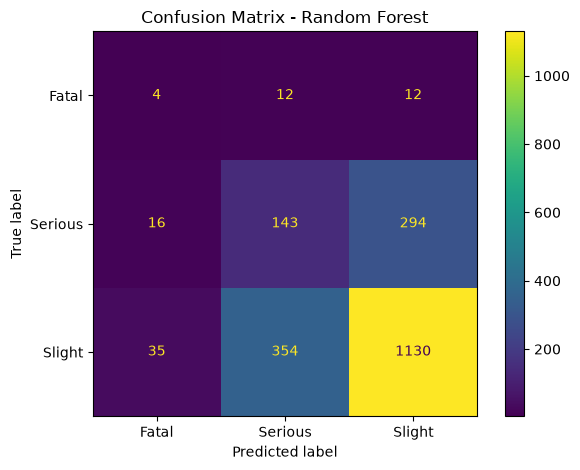

In [20]:
# ============================================
# CONFUSION MATRIX
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=labels,
    display_labels=labels,
    xticks_rotation=0,
)

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()


In [21]:
# ============================================
# FINAL LABEL VALIDATION
# ============================================

print("Tipe y_test:", y_test.dtype)
print("Nilai unik y_test:", sorted(y_test.unique().tolist()))
print("Tipe y_pred_rf:", y_pred_rf.dtype)
print("Nilai unik y_pred_rf:", sorted(pd.Series(y_pred_rf).unique().tolist()))


Tipe y_test: str
Nilai unik y_test: ['Fatal', 'Serious', 'Slight']
Tipe y_pred_rf: object
Nilai unik y_pred_rf: ['Fatal', 'Serious', 'Slight']
